In [10]:
# Data manipulation and analysis
import pandas as pd          # For data manipulation and analysis
import numpy as np           # For numerical operations

# Data visualization
import matplotlib.pyplot as plt  # For creating static, animated, and interactive visualizations
import seaborn as sns           # For statistical data visualization

# Geospatial data handling
import geopandas as gpd         # For working with geospatial data
from shapely.geometry import Point  # For geometric operations

# Time series analysis
import datetime as dt           # For handling date and time
import statsmodels.api as sm     # For statistical modeling

# Machine learning (if applicable)
from sklearn.model_selection import train_test_split  # For splitting datasets
from sklearn.ensemble import RandomForestRegressor     # Example model
from sklearn.metrics import mean_squared_error         # For evaluating model performance

# Web scraping (if needed)
import requests                  # For making HTTP requests
from bs4 import BeautifulSoup     # For parsing HTML and XML documents

# Environmental data libraries (if applicable)
import airquality                # Hypothetical library for air quality data (replace with actual library if available)

# Additional libraries
import json                      # For handling JSON data
import os                        # For operating system dependent functionality


ModuleNotFoundError: No module named 'airquality'

In [ ]:
!pip install matplotlib

In [ ]:
pip install --upgrade pip


In [ ]:
# Data manipulation and analysis
import pandas as pd          # For data manipulation and analysis
import numpy as np           # For numerical operations

# Data visualization
import matplotlib.pyplot as plt  # For creating static, animated, and interactive visualizations
import seaborn as sns           # For statistical data visualization

# Geospatial data handling
import geopandas as gpd         # For working with geospatial data
from shapely.geometry import Point  # For geometric operations

# Time series analysis
import datetime as dt           # For handling date and time
import statsmodels.api as sm     # For statistical modeling

# Machine learning (if applicable)
from sklearn.model_selection import train_test_split  # For splitting datasets
from sklearn.ensemble import RandomForestRegressor     # Example model
from sklearn.metrics import mean_squared_error         # For evaluating model performance

# Web scraping (if needed)
import requests                  # For making HTTP requests
from bs4 import BeautifulSoup     # For parsing HTML and XML documents

# Environmental data libraries (if applicable)
import airquality                # Hypothetical library for air quality data (replace with actual library if available)

# Additional libraries
import json                      # For handling JSON data
import os                        # For operating system dependent functionality


In [ ]:
pip list

In [ ]:
pip install seaborn geopandas statsmodels scikit-learn

In [ ]:
pip install gspread oauth2client

In [ ]:
import pandas as pd

url = r"C:\Users\sidhu\Downloads\Air_Quality.csv"
df = pd.read_csv(url)
pd.set_option('display.max_columns', None)
print(df.head(50))


In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a datetime column and 'pm25' is the pollutant concentration
df['Date'] = pd.to_datetime(df['Date'])  # Convert to datetime if necessary
plt.figure(figsize=(7, 3))
plt.plot(df['Date'], df['PM2.5'], label='PM2.5', color='red')
plt.title('PM2.5 Concentration Over Time')
plt.xlabel('Date')
plt.ylabel('Concentration (µg/m³)')
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot([df['PM2.5'], df['PM10'], df['NO2']], labels=['PM2.5', 'PM10', 'NO2'])
plt.title('Box Plot of Air Quality Metrics')
plt.ylabel('Concentration (µg/m³)')
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['PM2.5'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of PM2.5 Concentrations')
plt.xlabel('Concentration (µg/m³)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the CSV
url = r"C:\Users\sidhu\Downloads\Air_Quality.csv"
df = pd.read_csv(url)

# Quick look at the data
print(df.head())
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Save them if needed
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)
print(df.test())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data and parse 'Date' column as datetime
df = pd.read_csv(url, parse_dates=['Date'])
df = df.sort_values('Date')

# Plot AQI over time
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['AQI'], label='AQI', color='green')
plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("AQI Over Time")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap (example pollutants — adjust as per your dataset)
plt.figure(figsize=(8, 6))
sns.heatmap(df[['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Pollutants")
plt.show()


In [ ]:
max_aqi = df['AQI'].max()
max_row = df[df['AQI'] == max_aqi].iloc[0]
max_time = max_row['Date']

print(f"📍 Peak AQI: {max_aqi} at {max_time}")

In [ ]:
pip install pandas numpy matplotlib scikit-learn tensorflow

In [ ]:
pip list

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV
df = pd.read_csv(r"C:\Users\sidhu\Downloads\Air_Quality.csv", parse_dates=['Date'])
df = df.sort_values('Date')

# Use only AQI column
aqi_data = df[['Date', 'AQI']].copy()
aqi_data.dropna(inplace=True)

# Normalize AQI for LSTM
scaler = MinMaxScaler()
aqi_data['AQI_scaled'] = scaler.fit_transform(aqi_data[['AQI']])


In [ ]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 30  # Use past 30 days to predict next AQI
data = aqi_data['AQI_scaled'].values
X, y = create_sequences(data, window_size)

# Reshape for LSTM input: (samples, time_steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

# Predict on test set
predicted = model.predict(X_test)
predicted_actual = scaler.inverse_transform(predicted)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual AQI')
plt.plot(predicted_actual, label='Predicted AQI')
plt.title("AQI Prediction vs Actual")
plt.xlabel("Time (days)")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
python3.10 -m venv tfenv
tfenv\Scripts\activate


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

# Predict on test set
predicted = model.predict(X_test)
predicted_actual = scaler.inverse_transform(predicted)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual AQI')
plt.plot(predicted_actual, label='Predicted AQI')
plt.title("AQI Prediction vs Actual")
plt.xlabel("Time (days)")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
pip install python==3.10

In [ ]:
{
     "argv": [
      "python3.11",
      "-m",
      "ipykernel_launcher",
      "-f",
      "{connection_file}"
     ],
     "display_name": "Python 3 (ipykernel)",
     "language": "python",
     "metadata": {
      "debugger": True
     }
    }

In [ ]:
import sys
print("Python version:", sys.version)

In [11]:
print(df.head())

                       Date      City     CO    NO2   SO2    O3  PM2.5  PM10  \
0 2023-01-01 00:00:00+00:00  Brasilia  292.0  30.15  1.10  23.0   11.1  15.8   
1 2023-01-01 01:00:00+00:00  Brasilia  291.0  28.95  1.15  24.0   12.4  17.7   
2 2023-01-01 02:00:00+00:00  Brasilia  289.0  27.25  1.25  25.0   13.0  18.5   
3 2023-01-01 03:00:00+00:00  Brasilia  275.0  23.70  1.30  28.0    9.2  13.1   
4 2023-01-01 04:00:00+00:00  Brasilia  246.0  19.35  1.25  32.0    6.8   9.7   

         AQI  
0  21.158330  
1  20.825000  
2  20.474998  
3  20.074999  
4  19.324999  


In [16]:
max_aqi = df['AQI'].max()
max_row = df[df['AQI'] == max_aqi].iloc[0]
max_time = max_row['Date']
max_city = max_row.get('City')

print(f"📍 Peak AQI: {max_aqi} at {max_time}")

📍 Peak AQI: 188.31998 at 2023-09-12 19:00:00+00:00


In [17]:
print(df.columns)

Index(['Date', 'City', 'CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI'], dtype='object')


In [19]:
max_aqi = df['AQI'].max()
max_row = df[df['AQI'] == max_aqi].iloc[0]
max_time = max_row['Date']

# Try common location field names
location_fields = ['City']
max_city = next((max_row[col] for col in location_fields if col in max_row and pd.notna(max_row[col])), "Unknown")

print(f"📍 Peak AQI: {max_aqi} at {max_time} in {max_city}")


📍 Peak AQI: 188.31998 at 2023-09-12 19:00:00+00:00 in Cairo


In [20]:
import sys
print("Python version:", sys.version)

Python version: 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


In [21]:
print(df.head(50))

                        Date      City     CO    NO2   SO2    O3  PM2.5  PM10  \
0  2023-01-01 00:00:00+00:00  Brasilia  292.0  30.15  1.10  23.0   11.1  15.8   
1  2023-01-01 01:00:00+00:00  Brasilia  291.0  28.95  1.15  24.0   12.4  17.7   
2  2023-01-01 02:00:00+00:00  Brasilia  289.0  27.25  1.25  25.0   13.0  18.5   
3  2023-01-01 03:00:00+00:00  Brasilia  275.0  23.70  1.30  28.0    9.2  13.1   
4  2023-01-01 04:00:00+00:00  Brasilia  246.0  19.35  1.25  32.0    6.8   9.7   
5  2023-01-01 05:00:00+00:00  Brasilia  208.0  13.95  1.15  36.0    5.6   8.0   
6  2023-01-01 06:00:00+00:00  Brasilia  166.0   8.20  1.05  41.0    5.1   7.2   
7  2023-01-01 07:00:00+00:00  Brasilia  152.0   6.30  1.00  41.0    4.9   6.9   
8  2023-01-01 08:00:00+00:00  Brasilia  146.0   5.55  0.95  40.0    4.9   7.0   
9  2023-01-01 09:00:00+00:00  Brasilia  139.0   4.90  0.90  40.0    4.9   7.0   
10 2023-01-01 10:00:00+00:00  Brasilia  130.0   4.15  0.90  44.0    4.1   5.8   
11 2023-01-01 11:00:00+00:00

C:\Users\sidhu\anaconda4\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 101s 35ms/step - loss: 0.0190 - val_loss: 0.0138
Epoch 2/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 91s 35ms/step - loss: 0.0175 - val_loss: 0.0150
Epoch 3/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 98s 37ms/step - loss: 0.0173 - val_loss: 0.0137
Epoch 4/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 96s 37ms/step - loss: 0.0174 - val_loss: 0.0138
Epoch 5/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 95s 36ms/step - loss: 0.0175 - val_loss: 0.0137
Epoch 6/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 97s 37ms/step - loss: 0.0173 - val_loss: 0.0137
Epoch 7/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 95s 36ms/step - loss: 0.0169 - val_loss: 0.0139
Epoch 8/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 94s 36ms/step - loss: 0.0172 - val_loss: 0.0140
Epoch 9/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 93s 35ms/step - loss: 0.0172 - val_loss: 0.0137
Epoch 10/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 92s 35ms/step - loss: 0.0173 - val_loss: 0.0139
Epoch 11/30
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 93s 35ms/step - loss: 0.0176 - val_loss: 0.0137
Epoch 1

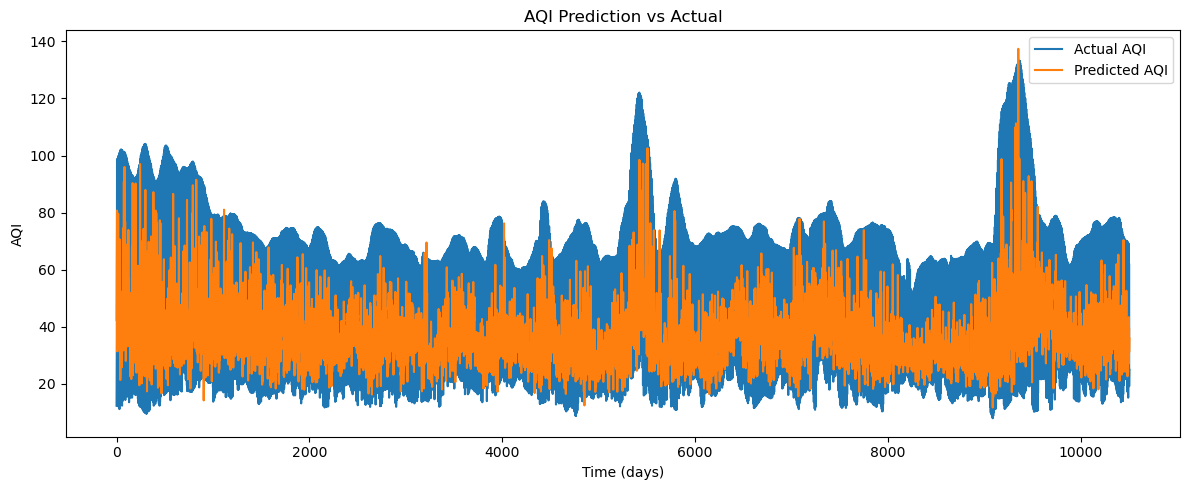

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load the CSV
df = pd.read_csv(r"C:\Users\sidhu\Downloads\Air_Quality.csv", parse_dates=['Date'])
df = df.sort_values('Date')

# Use only AQI column
aqi_data = df[['Date', 'AQI']].copy()
aqi_data.dropna(inplace=True)

# Normalize AQI for LSTM
scaler = MinMaxScaler()
aqi_data['AQI_scaled'] = scaler.fit_transform(aqi_data[['AQI']])


def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 30  # Use past 30 days to predict next AQI
data = aqi_data['AQI_scaled'].values
X, y = create_sequences(data, window_size)

# Reshape for LSTM input: (samples, time_steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

# Predict on test set
predicted = model.predict(X_test)
predicted_actual = scaler.inverse_transform(predicted)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual AQI')
plt.plot(predicted_actual, label='Predicted AQI')
plt.title("AQI Prediction vs Actual")
plt.xlabel("Time (days)")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Convert predicted and actual back from scaled values (already done in your code)
y_true = y_test_actual.flatten()
y_pred = predicted_actual.flatten()

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# Print results
print(f"📊 MAE: {mae:.2f}")
print(f"📊 MSE: {mse:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📈 R² Score: {r2:.4f}")




📊 MAE: 16.35
📊 MSE: 419.54
📊 RMSE: 20.48
📈 R² Score: 0.1888


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# === 1. Load and Preprocess Data ===
df = pd.read_csv(r"C:\Users\sidhu\Downloads\Air_Quality.csv", parse_dates=['Date'])
df = df.sort_values('Date')
df = df.dropna(subset=['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'])

# Add date-based features
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# === 2. Scale features and AQI separately ===
feature_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Day', 'Month', 'DayOfWeek']
target_col = 'AQI'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

df_features_scaled = feature_scaler.fit_transform(df[feature_cols])
df_target_scaled = target_scaler.fit_transform(df[[target_col]])

# Combine scaled features and target into one array
scaled_data = np.hstack([df_features_scaled, df_target_scaled])

# === 3. Create Sequences ===
def create_multivariate_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :-1])  # all features except target
        y.append(data[i, -1])                 # target is last column
    return np.array(X), np.array(y)

window_size = 30
X, y = create_multivariate_sequences(scaled_data, window_size)

# === 4. Train/Test Split ===
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# === 5. Define and Train LSTM Model ===
model = Sequential([
    Input(shape=(window_size, X.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train, y_train,
    epochs=2,              # Reduced epochs
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# === 6. Make Predictions and Inverse Transform ===
predicted_scaled = model.predict(X_test)
predicted_actual = target_scaler.inverse_transform(predicted_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# === 7. Evaluation Metrics ===
mae = mean_absolute_error(y_test_actual, predicted_actual)
mse = mean_squared_error(y_test_actual, predicted_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, predicted_actual)

print(f"📊 MAE: {mae:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📈 R² Score: {r2:.4f}")

# === 8. Plot Actual vs Predicted ===
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual AQI')
plt.plot(predicted_actual, label='Predicted AQI')
plt.title("AQI Prediction vs Actual (Multivariate LSTM)")
plt.xlabel("Time (days)")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()
print("Training Complete")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# === 1. Load and Preprocess Data ===
df = pd.read_csv(r"C:\Users\sidhu\Downloads\Air_Quality.csv", parse_dates=['Date'])
df = df.sort_values('Date')
df = df.dropna(subset=['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'])

# Add date-based features
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# === 2. Scale features and AQI separately ===
feature_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Day', 'Month', 'DayOfWeek']
target_col = 'AQI'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

df_features_scaled = feature_scaler.fit_transform(df[feature_cols])
df_target_scaled = target_scaler.fit_transform(df[[target_col]])

# Combine scaled features and target into one array
scaled_data = np.hstack([df_features_scaled, df_target_scaled])

# === 3. Create Sequences ===
def create_multivariate_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :-1])  # all features except target
        y.append(data[i, -1])                 # target is last column
    return np.array(X), np.array(y)

window_size = 30
X, y = create_multivariate_sequences(scaled_data, window_size)

# === 4. Train/Test Split ===
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# === 5. Define and Train LSTM Model ===
model = Sequential([
    Input(shape=(window_size, X.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train, y_train,
    epochs=2,              # Reduced epochs
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# === 6. Make Predictions and Inverse Transform ===
predicted_scaled = model.predict(X_test)
predicted_actual = target_scaler.inverse_transform(predicted_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# === 7. Evaluation Metrics ===
mae = mean_absolute_error(y_test_actual, predicted_actual)
mse = mean_squared_error(y_test_actual, predicted_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, predicted_actual)

print(f" MAE: {mae:.2f}")
print(f" RMSE: {rmse:.2f}")
print(f" R² Score: {r2:.4f}")

# === 8. Plot Actual vs Predicted ===
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual AQI')
plt.plot(predicted_actual, label='Predicted AQI')
plt.title("AQI Prediction vs Actual (Multivariate LSTM)")
plt.xlabel("Time (days)")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()
print("Training Complete")


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# === 1. Load and Preprocess Data ===
df = pd.read_csv(r"C:\Users\sidhu\Downloads\Air_Quality.csv", parse_dates=['Date'])
df = df.sort_values('Date')
df = df.dropna(subset=['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'])

In [2]:
# Add date-based features
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# === 2. Scale features and AQI separately ===
feature_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Day', 'Month', 'DayOfWeek']
target_col = 'AQI'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

df_features_scaled = feature_scaler.fit_transform(df[feature_cols])
df_target_scaled = target_scaler.fit_transform(df[[target_col]])

In [3]:
# Combine scaled features and target into one array
scaled_data = np.hstack([df_features_scaled, df_target_scaled])

# === 3. Create Sequences ===
def create_multivariate_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :-1])  # all features except target
        y.append(data[i, -1])                 # target is last column
    return np.array(X), np.array(y)

window_size = 30
X, y = create_multivariate_sequences(scaled_data, window_size)

# === 4. Train/Test Split ===
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


Epoch 1/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 0.0197 - val_loss: 0.0151
Epoch 2/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0181 - val_loss: 0.0154
Epoch 3/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 0.0181 - val_loss: 0.0147
Epoch 4/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0179 - val_loss: 0.0144
Epoch 5/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 0.0176 - val_loss: 0.0144
Epoch 6/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 0.0177 - val_loss: 0.0142
Epoch 7/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0173 - val_loss: 0.0145
Epoch 8/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 0.0177 - val_loss: 0.0143
Epoch 9/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0175 - val_loss: 0.0144
Epoch 10/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0175 - val_loss: 0.0149
Epoch 11/60
2627/2627 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0175 - val_loss: 0.0148
Epoch 12

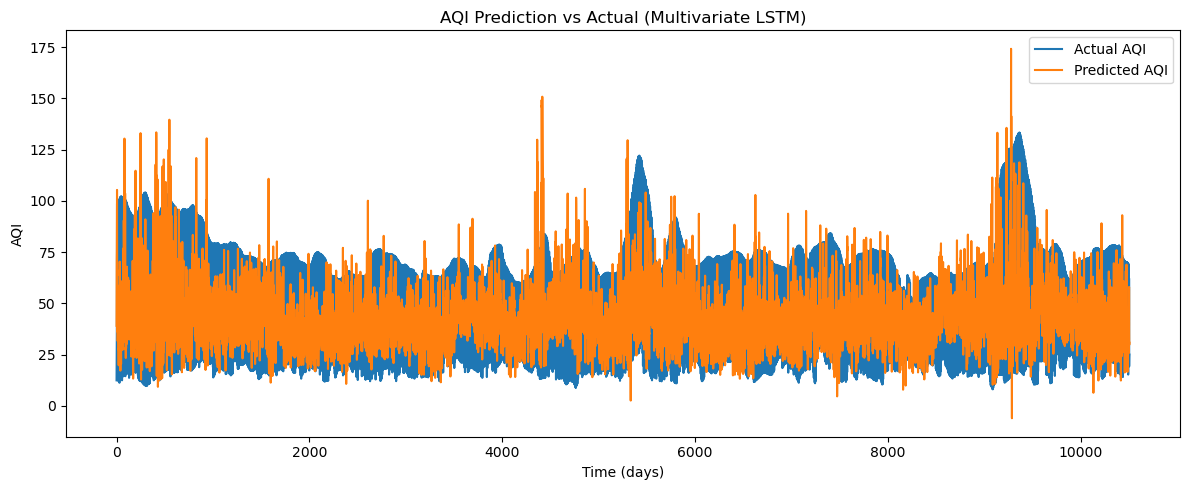

Training Complete


In [5]:
# === 5. Define and Train LSTM Model ===
model = Sequential([
    Input(shape=(window_size, X.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train, y_train,
    epochs=60,              
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# === 6. Make Predictions and Inverse Transform ===
predicted_scaled = model.predict(X_test)
predicted_actual = target_scaler.inverse_transform(predicted_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# === 7. Evaluation Metrics ===
mae = mean_absolute_error(y_test_actual, predicted_actual)
mse = mean_squared_error(y_test_actual, predicted_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, predicted_actual)

print(f" MAE: {mae:.2f}")
print(f" RMSE: {rmse:.2f}")
print(f" R² Score: {r2:.4f}")

# === 8. Plot Actual vs Predicted ===
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual AQI')
plt.plot(predicted_actual, label='Predicted AQI')
plt.title("AQI Prediction vs Actual (Multivariate LSTM)")
plt.xlabel("Time (days)")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()
print("Training Complete")


In [6]:
pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/29/22/e3ff2dfafe862a91733dfa0aecdb4794aa1d9a18e09a14e118bde0cbc2db/xgboost-3.0.2-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB 495.5 kB/s eta 0:05:03
   ---------------------------------------- 0.1/150.0 MB 819.2 kB/s eta 0:03:03
   ---------------------------------------- 0.2/150.0 MB 1.3 MB/s eta 0:02:00
   ---------------------------------------- 0.4/150.0 MB 1.7 MB/s eta 0:01:27
   ---------------------------------------- 0.6/150.0 MB 2.2 MB/s eta 0:01:10
   ---------------------------------------- 0.8/150.0 MB 2.5 MB/s eta 0:01:00
   ---------------------------------------- 1.1/150.0 MB 2.9 MB/s eta 0:00:51
   ---------------------------------------- 1.2/150.0 MB 2.8 MB/s eta 0:00:54
   ----------------------

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# === 1. Load and Preprocess Data ===
df = pd.read_csv(r"C:\Users\sidhu\Downloads\Air_Quality.csv", parse_dates=['Date'])
df = df.sort_values('Date')
df = df.dropna(subset=['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'])

# Add date-based features
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Optionally: Add lag feature for AQI
df['AQI_lag1'] = df['AQI'].shift(1)
df = df.dropna()  # drop NaN from shift

# === 2. Prepare Features ===
feature_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Day', 'Month', 'DayOfWeek', 'AQI_lag1']
target_col = 'AQI'

X = df[feature_cols]
y = df[target_col]

# === 3. Normalize Features (optional, not mandatory for tree-based models) ===
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# === 4. Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# === 5A. Train Random Forest ===
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# === 5B. Train XGBoost ===
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)


 Random Forest Results:
   MAE:  3.79
   RMSE: 6.50
   R²:   0.9330
------------------------------
 XGBoost Results:
   MAE:  4.68
   RMSE: 7.44
   R²:   0.9121
------------------------------


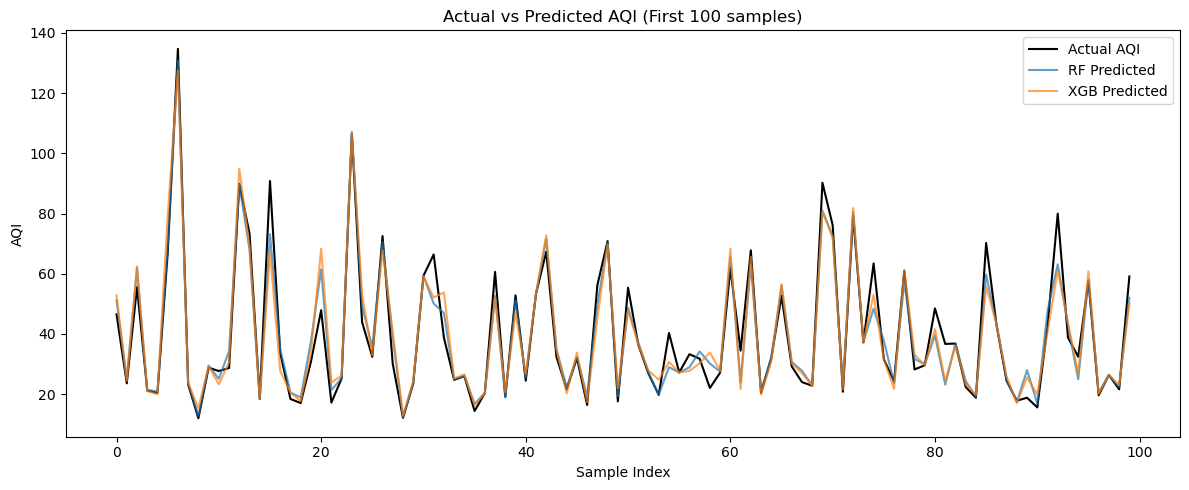

In [3]:
# === 6. Evaluate ===
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f" {name} Results:")
    print(f"   MAE:  {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   R²:   {r2:.4f}")
    print("-" * 30)

evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)

# === 7. Plot Predictions ===
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label="Actual AQI", color="black")
plt.plot(rf_preds[:100], label="RF Predicted", alpha=0.7)
plt.plot(xgb_preds[:100], label="XGB Predicted", alpha=0.7)
plt.title("Actual vs Predicted AQI (First 100 samples)")
plt.xlabel("Sample Index")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np

# Assume you already have: `rf` (trained Random Forest), `scaler` (MinMaxScaler), and `feature_cols`

# Start with the last available row as base
latest_data = df.copy().iloc[-1:].copy()

# Store predictions
future_predictions = []

# Forecast for the next 7 days
for day in range(1, 8):
    # Advance date
    latest_data['Date'] = latest_data['Date'] + pd.Timedelta(days=1)
    latest_data['Day'] = latest_data['Date'].dt.day
    latest_data['Month'] = latest_data['Date'].dt.month
    latest_data['DayOfWeek'] = latest_data['Date'].dt.dayofweek
    
    # Use last predicted AQI as lag1 (if no prediction yet, use last actual AQI)
    if future_predictions:
        latest_data['AQI_lag1'] = future_predictions[-1]
    else:
        latest_data['AQI_lag1'] = latest_data['AQI'].values[0]

    # Use previous values for other pollutants (assume no new data)
    input_features = latest_data[feature_cols].values
    input_df = pd.DataFrame(input_features, columns=feature_cols)
    input_scaled = scaler.transform(input_df)

    # Predict
    pred_aqi = rf.predict(input_scaled)[0]
    future_predictions.append(pred_aqi)

    # Update AQI for next iteration
    latest_data['AQI'] = pred_aqi

# Output forecast
forecast_dates = pd.date_range(start=df['Date'].iloc[-1] + pd.Timedelta(days=1), periods=7)
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Predicted AQI': np.round(future_predictions, 2)
})

print("📅 AQI Forecast for Next 7 Days:")
print(forecast_df)


📅 AQI Forecast for Next 7 Days:
                       Date  Predicted AQI
0 2024-01-01 23:00:00+00:00          23.22
1 2024-01-02 23:00:00+00:00          23.39
2 2024-01-03 23:00:00+00:00          23.67
3 2024-01-04 23:00:00+00:00          24.33
4 2024-01-05 23:00:00+00:00          24.36
5 2024-01-06 23:00:00+00:00          23.52
6 2024-01-07 23:00:00+00:00          23.62
